<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/LinearRegression%EC%9D%84_%EC%9D%B4%EC%9A%A9%ED%95%9C_%EC%BA%98%EB%A6%AC%ED%8F%AC%EB%8B%88%EC%95%84_%EC%A3%BC%ED%83%9D_%EA%B0%80%EA%B2%A9_%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
class sklearn.linear_model.LinearRegression(fit_intercept=True,normalize=False,copy_X=True,n_jobs=1)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

housing=fetch_california_housing()
housing.keys()
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
df['price']=housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


20640개의 행이 존재하고 9개의 칼럼이 있으며 피처들이 모두 float 형이다. 모든 피처들이 결측치가 없다.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


선형 모델을 사용하기 때문에 스케일링으로 StandardScaler()를 사용한다.

In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


price 변수와 MedInc 변수가 양의 선형 관계를 가지는 것을 확인할 수 있다. Medlnc가 증가할수록 price도 증가하는 것을 알수 있다.

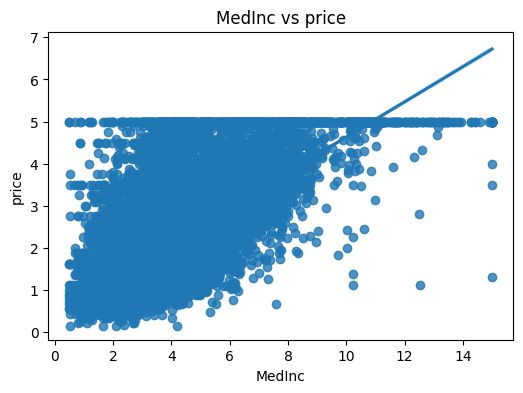

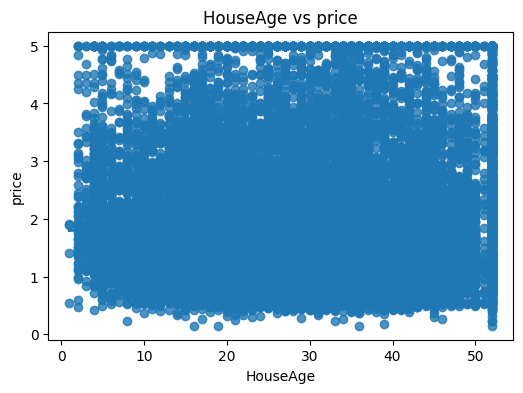

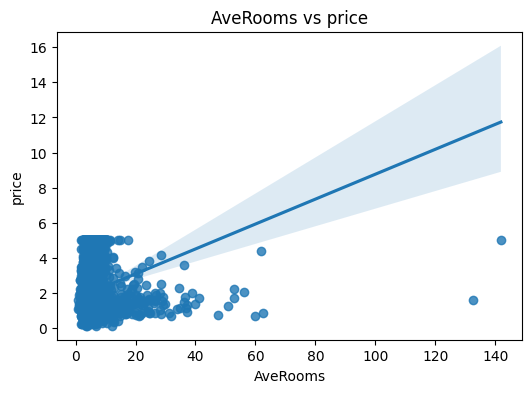

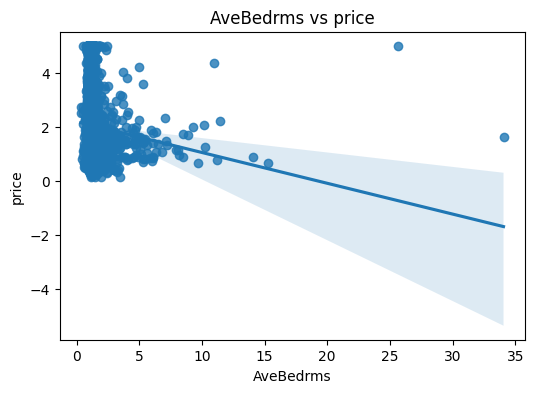

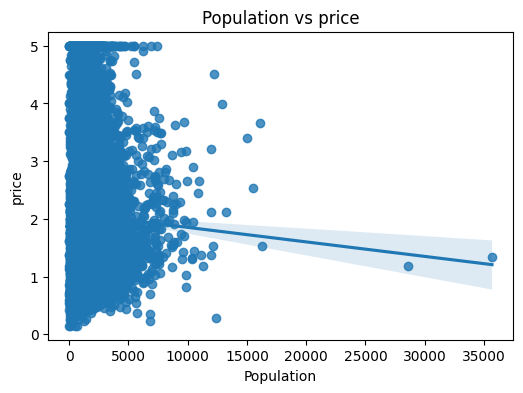

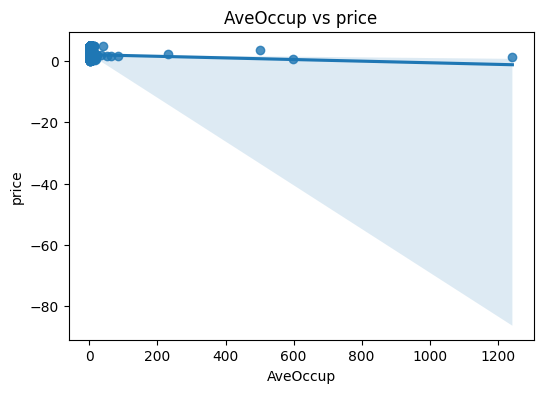

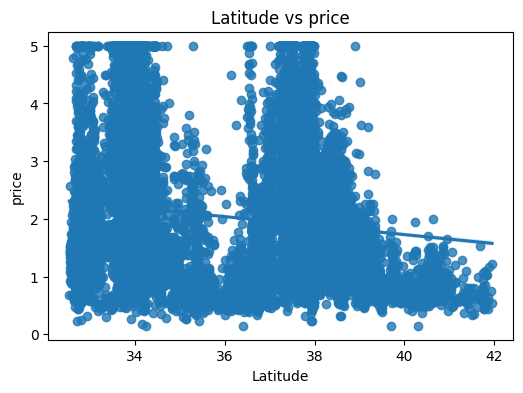

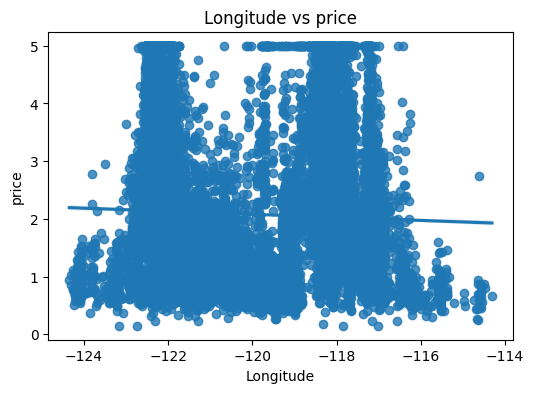

In [29]:
columns=df.columns.values.tolist()

for col in columns:
  if col != 'price':
    plt.figure(figsize=(6,4))
    sns.regplot(x=df[col],y=df['price'])
    plt.title(f'{col} vs price')
    plt.show()

선형 회귀 모델은 피처의 분산에 모델이 예민하기 때문에 HouseAge,Population,AveOccup 칼럼들은 스케일링을 적용해야함

상관관계 확인

AveRooms(가구당 평균 방의 개수)와 AveBedrms(가구당 평균 침실 개수) 피처들 간의 양의 상관관계가 높다.

Latitude(위도)와 Longitude(경도)는 음의 상관관계가 높다.
-> 위도가 커질수록 경도는 작이지는 경향이 있다.

HouseAge(해당 지역 주택의 중위 연식)와 Population(해당 지역 인구 수)의 약한 상관관계를 가진다.

<Axes: >

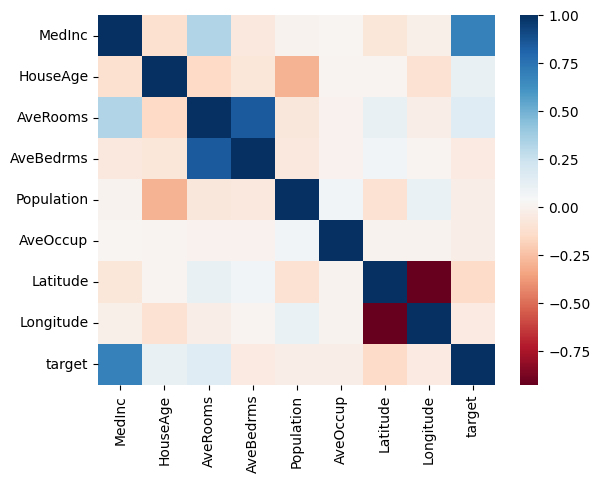

In [14]:
df_corr = df.corr()
sns.heatmap(df_corr,cmap='RdBu')

위치 별 가격이 높은 지 시각화를 통해 확인해보자

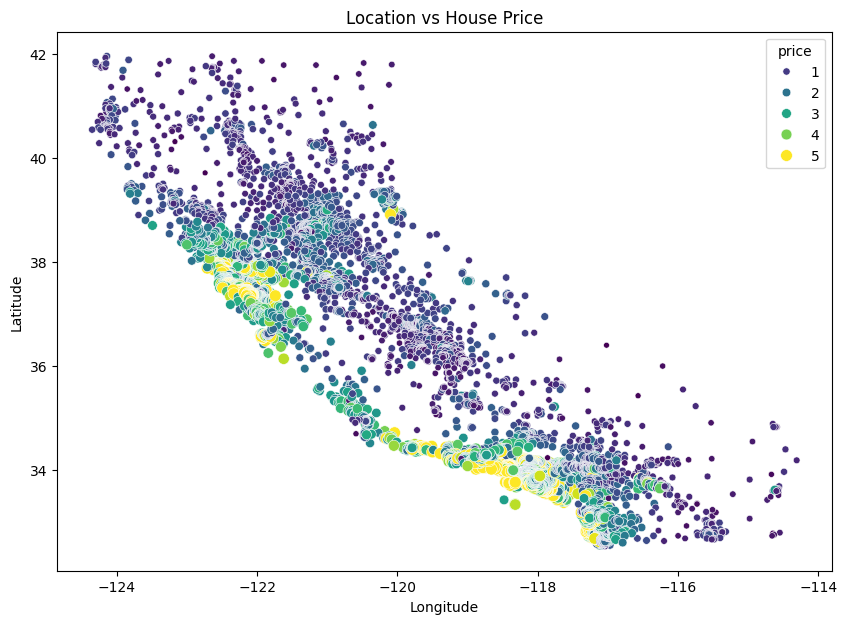

In [20]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df['Longitude'],
    y=df['Latitude'],
    hue=df['price'],
    size=df['price'],
    palette='viridis'
)

plt.title('Location vs House Price')
plt.show()

Latitude와 Longitude는 높은 음의 상관관계를 보였는데, 이는 캘리포니아 지역의 지리적 특성에 따른 자연스러운 결과로 해석할 수 있습니다. 또한 위도와 경도를 이용한 산점도 시각화를 통해 특정 지역, 특히 해안가 및 주요 도시 주변에서 주택 가격이 높게 형성되는 경향을 확인할 수 있습니다.

In [34]:
from sklearn.model_selection import train_test_split
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=156)

In [35]:
# 데이터스케일링
from sklearn.preprocessing import StandardScaler

cols=['HouseAge','Population','AveOccup']

scaler=StandardScaler()

# train은 fit + transform
X_train[cols]=scaler.fit_transform(X_train[cols])
# test는 transform만
X_test[cols]=scaler.transform(X_test[cols])

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

lr = LinearRegression()
lr.fit(X_train,y_train)
pred = lr.predict(X_test)
mse = mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)

print(f'MSE:{mse:.4f}, RMSE:{rmse:.4f}, r2_score:{r2_score(y_test,pred)}')

MSE:0.5584, RMSE:0.7473, r2_score:0.5808818883046771


In [38]:
print(f"절편 값:{lr.intercept_:.4f}")
print(f"회귀계수:{lr.coef_}")

절편 값:-36.4842
회귀계수:[ 4.35315175e-01  1.25072321e-01 -1.01245997e-01  6.08198410e-01
  2.20800434e-04 -4.25545751e-02 -4.21457690e-01 -4.32930805e-01]


변수 제거

In [28]:
# 다중공선성 체크
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif=pd.DataFrame()
vif['Feature']=X.columns
vif['VIF']=[
    variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]

print(vif.sort_values(by='VIF',ascending=False))

      Feature         VIF
7   Longitude  633.711654
6    Latitude  559.874071
2    AveRooms   45.993601
3   AveBedrms   43.590314
0      MedInc   11.511140
1    HouseAge    7.195917
4  Population    2.935745
5    AveOccup    1.095243


AveRooms 칼럼과 AveBedrms 칼럼중 타켓과 약한 양의 상관성이 있는 AveRooms가 아닌 AveBedrms를 제거하겠다.

In [42]:
from sklearn.model_selection import train_test_split

df_drop = df.drop('AveBedrms',axis=1)
X=df_drop.iloc[:,:-1]
y=df_drop.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=156)

다중공선성이 높고 target과 상관성이 더 낮은 AveBedrms를 제거한 경우 모델링 결과가 더 좋음

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

lr = LinearRegression()
lr.fit(X_train,y_train)
pred = lr.predict(X_test)
mse = mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)

print(f'MSE:{mse:.4f}, RMSE:{rmse:.4f}, r2_score:{r2_score(y_test,pred)}')

MSE:0.5764, RMSE:0.7592, r2_score:0.5673984858950474


In [44]:
print(f"절편 값:{lr.intercept_:.4f}")
print(f"회귀계수:{lr.coef_}")

절편 값:-38.8834
회귀계수:[ 3.71849714e-01  1.00963314e-02  1.73588614e-02  7.38907023e-07
 -8.28032215e-03 -4.57948034e-01 -4.63899109e-01]


coef_ 속성은 회귀 계수 값만 가지고 있으므로 이를 피처별 회귀 계수 값으로 다시 매핑하고, 높은 값 순을 출력해 보겠습니다.

In [46]:
coeff = pd.Series(data=np.round(lr.coef_,4),index=X.columns)
coeff.sort_values(ascending=False)

,0
MedInc,0.3718
AveRooms,0.0174
HouseAge,0.0101
Population,0.0000
AveOccup,-0.0083
Latitude,-0.4579
Longitude,-0.4639


```Medlnc``` 피처의 회귀계수는 0.3718로 양의 값으로 회귀 계수가 가장 큽니다.


```AveRooms``` 피처의 회귀계수는 0.0174로 평균 방 개수가 많을수록 주택 가격이 약간 증가하는 경향이 있습니다. 양의 방향이지만 영향력은 크지 않습니다.

```HouseAge``` 피처는 주택 연식이 높을수록 가격이 아주 조금 증가하는 경향이 있습니다. 거의 영향이 크지 않은 수준입니다.

```AveOccup``` 피처는 평균 거주 인원이 많을수록 가격이 약간 감소하는 경향이 있습니다. 영향은 매우 작습니다.


```Latitude```와 ```Longitude```의 회귀계수는 -0.5로 북쪽으로 갈수록 동쪽 방향으로 갈수록 집값이 낮아지는 경향이 있습니다. 위치 정보가 가격에 큰 영향을 주는 것을 의미합니다.

가장 중요한 변수는 ```Medlnc,Latitude,Longitude``` 입니다.

즉, 소득 수준과 위치 정보가 주택 가격을 결정하는 핵심 변수임을 알 수 있습니다.
